In [1]:
print("Hello. This is a script that will plot roofline and where a kernel is on it.")

Hello. This is a script that will plot roofline and where a kernel is on it.


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION: Theoretical Peaks (SXM5 Variants) ---
# Values approximate for A100 (40GB) and H100 (80GB)
gpu_configs = {
    'A100_FP32': {'peak_flops': 19500, 'peak_bw': 1935},   # Standard CUDA Cores
    'A100_TF32': {'peak_flops': 156000, 'peak_bw': 1935},  # TF32 Tensor Cores
    'A100_FP16': {'peak_flops': 312000, 'peak_bw': 1935}   # FP16 Tensor Cores
}

def plot_roofline(gpu_name, kernel_flops, kernel_bytes, kernel_time_ns):
    config = gpu_configs[gpu_name]
    peak_flops = config['peak_flops']
    peak_bw = config['peak_bw']
    
    # 1. Calculate Kernel Stats
    # AI = Total Flops / Total Bytes
    ai = kernel_flops / kernel_bytes
    # GFLOPS = (Total Flops / 1e9) / (Time in seconds)
    achieved_gflops = (kernel_flops / 1e9) / (kernel_time_ns / 1e9)
    
    # 1. Expand the range to cover the kernel's AI
    ai_range = np.logspace(-2, 3, 500) # Go up to 1000 AI
    
    # 2. Ensure the roofline reflects the peak_flops ceiling
    roofline = np.minimum(peak_flops, peak_bw * ai_range)
    
    # 3. Force the Y-axis to show the peak
    plt.ylim(10, peak_flops * 1.5)
    
    # 3. Plotting
    plt.figure(figsize=(10, 6))
    plt.loglog(ai_range, roofline, label=f'{gpu_name} Roofline', color='black', lw=2)
    plt.scatter(ai, achieved_gflops, color='red', marker='x', s=100, label='Your Kernel')
    
    # Efficiency calculation
    theoretical_max = min(peak_flops, peak_bw * ai)
    efficiency = (achieved_gflops / theoretical_max) * 100
    
    plt.title(f'Roofline Analysis: {gpu_name}\nEfficiency: {efficiency:.2f}% of Theoretical Max')
    plt.xlabel('Arithmetic Intensity (FLOP/Byte)')
    plt.ylabel('Performance (GFLOP/s)')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()

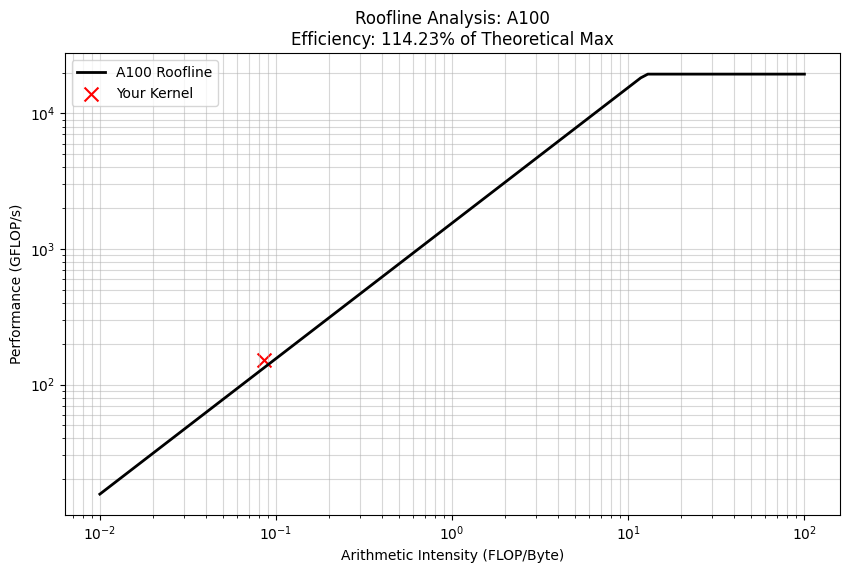

In [6]:
## A100 VECTOR ADD

plot_roofline(
    gpu_name='A100', 
    kernel_flops=33554432, 
    kernel_bytes=394.88e6, 
    kernel_time_ns=222300
)

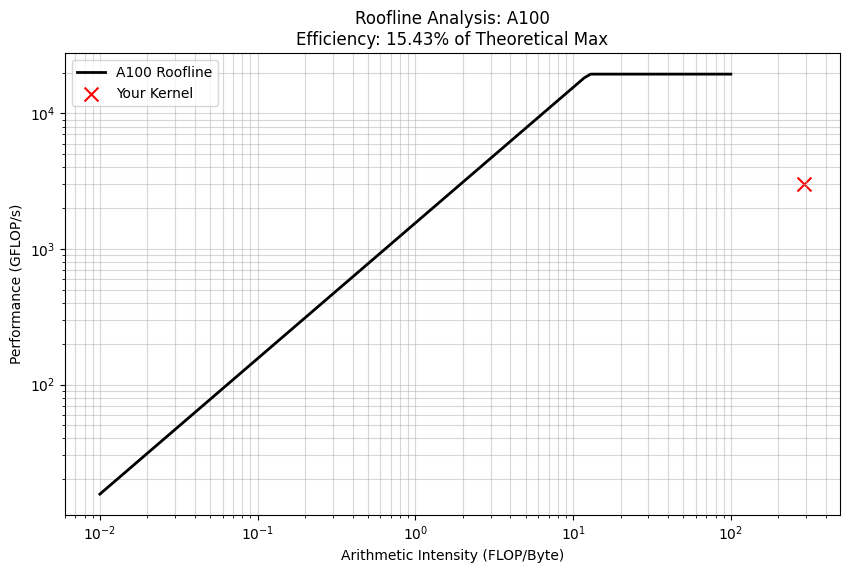

In [8]:
## A100 NATIVE GEMM
plot_roofline(
    gpu_name='A100', 
    kernel_flops=17179869184, 
    kernel_bytes=58.68e6, 
    kernel_time_ns=5710000
)

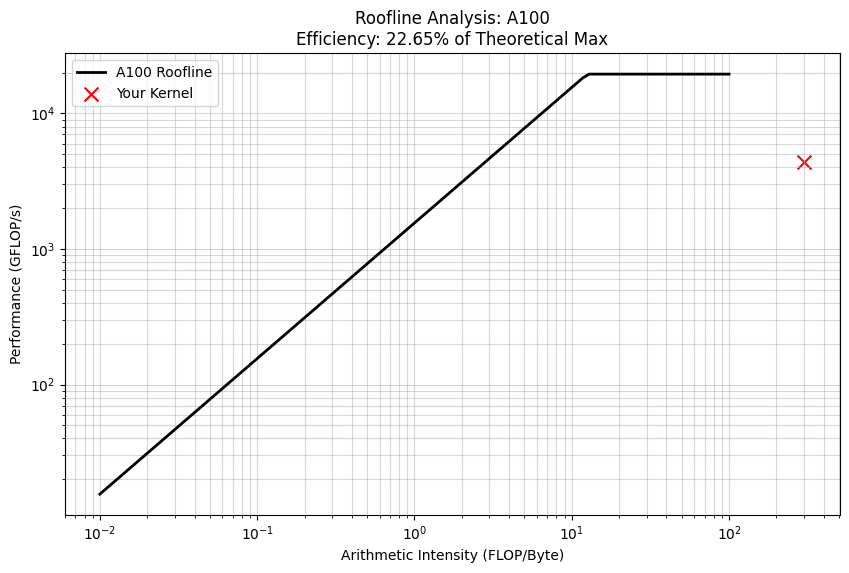

In [9]:
# sharedMemoryGEMM (A100)
plot_roofline(
    gpu_name='A100', 
    kernel_flops=17179869184, 
    kernel_bytes=56.99e6, 
    kernel_time_ns=3890000
)

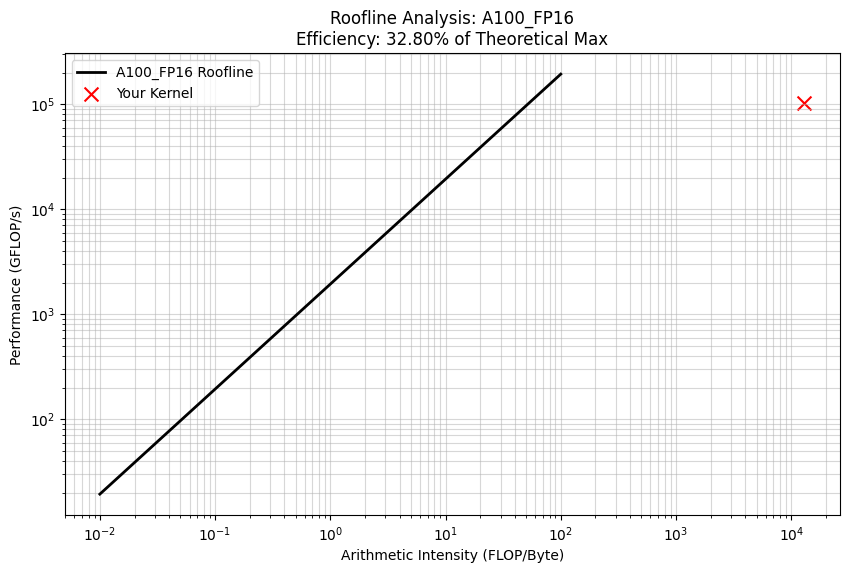

In [14]:
# tensorCoreGEMM (A100)
plot_roofline(
    gpu_name='A100_FP16',
    kernel_flops=17179869184, 
    kernel_bytes=1.32e6, 
    kernel_time_ns=167900
)

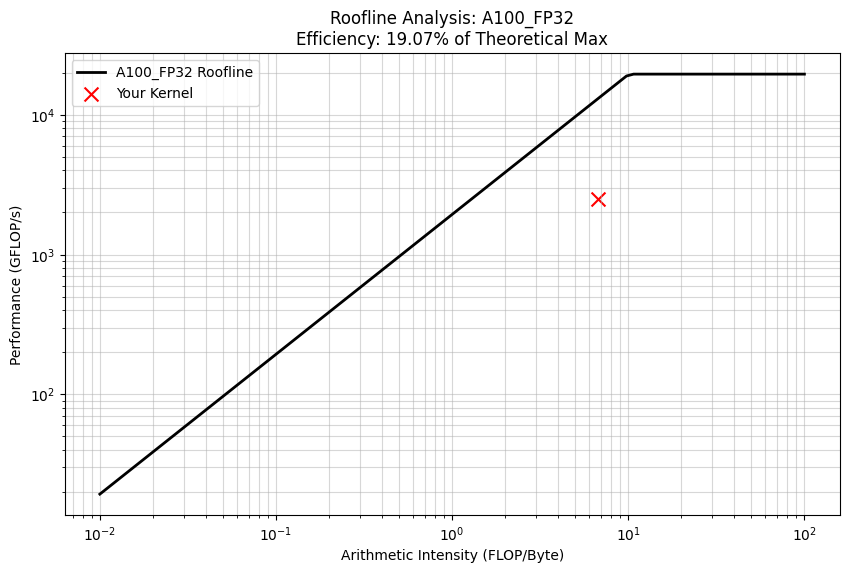

In [15]:
# naiveConv2d (A100)
plot_roofline(
    gpu_name='A100_FP32', 
    kernel_flops=838369352, 
    kernel_bytes=123.90e6, 
    kernel_time_ns=335840
)

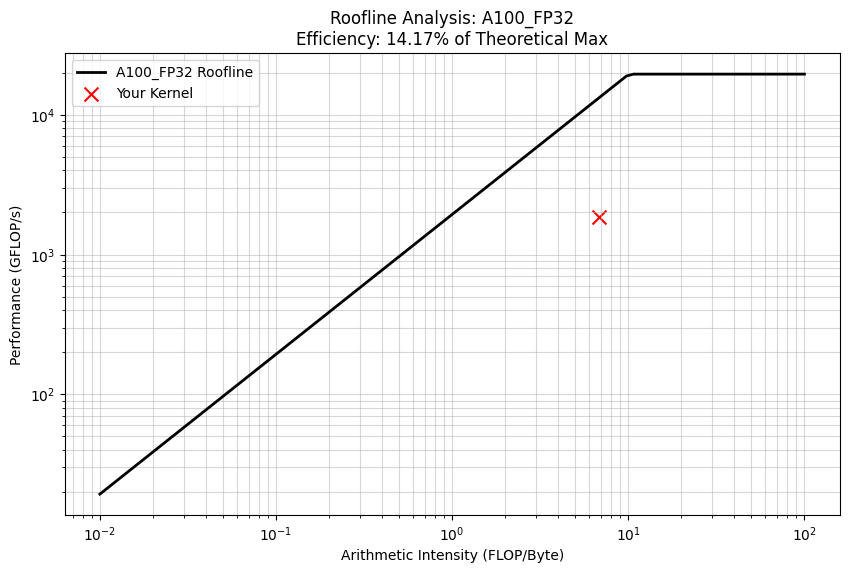

In [16]:
# sharedConv2d (A100)
plot_roofline(
    gpu_name='A100_FP32', 
    kernel_flops=838860800, 
    kernel_bytes=123.76e6, 
    kernel_time_ns=451420
)

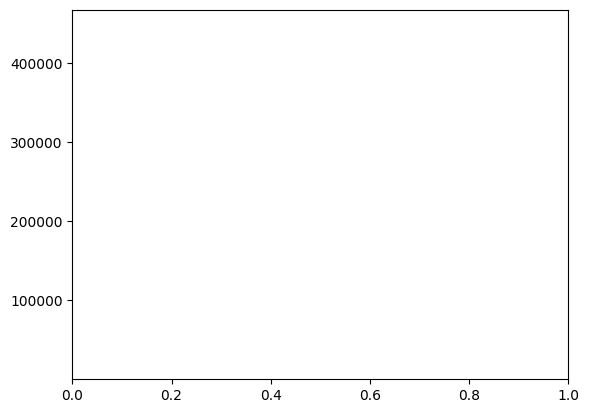

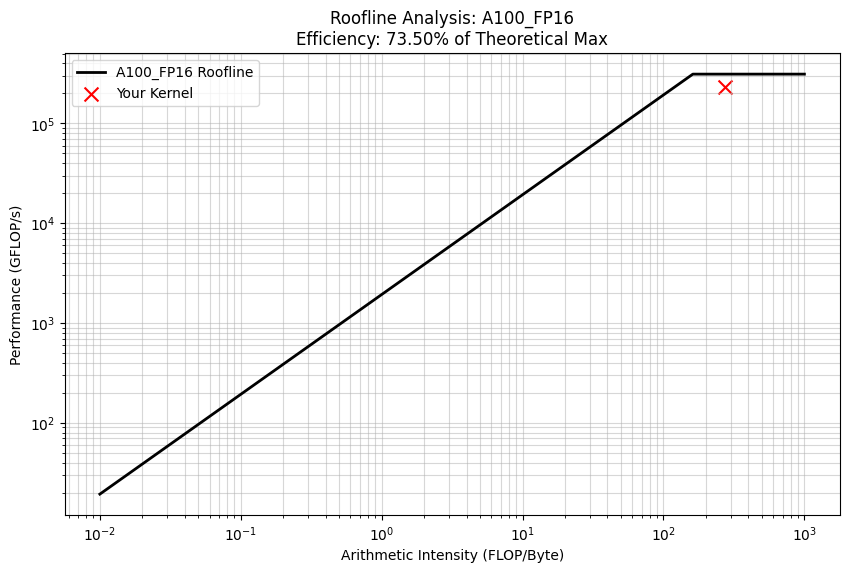

In [19]:
# FA2 APPROX NUMBERS ON A100
plot_roofline(
    gpu_name='A100_FP16', 
    kernel_flops=6.88e10, 
    kernel_bytes=0.25e9, 
    kernel_time_ns=300000
)

Flash AI: 275.2 | Naive AI: 114.7


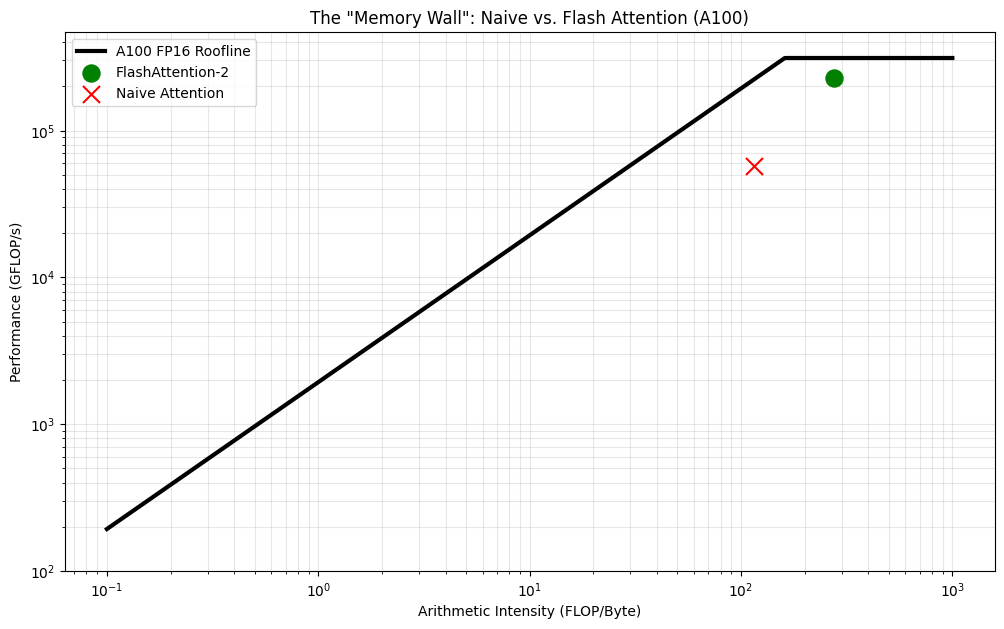

In [20]:
import matplotlib.pyplot as plt
import numpy as np

gpu_configs = {
    'A100_FP16': {'peak_flops': 312000, 'peak_bw': 1935} 
}

def plot_attention_comparison():
    config = gpu_configs['A100_FP16']
    peak_flops = config['peak_flops']
    peak_bw = config['peak_bw']
    
    # Setup Range: Wide enough to see both kernels
    ai_range = np.logspace(-1, 3, 1000)
    roofline = np.minimum(peak_flops, peak_bw * ai_range)
    
    plt.figure(figsize=(12, 7))
    plt.loglog(ai_range, roofline, label='A100 FP16 Roofline', color='black', lw=3)

    # --- 1. FLASH ATTENTION (Your current numbers) ---
    fa_flops, fa_bytes, fa_time = 6.88e10, 0.25e9, 300000
    fa_ai = fa_flops / fa_bytes
    fa_gflops = (fa_flops / 1e9) / (fa_time / 1e9)
    plt.scatter(fa_ai, fa_gflops, color='green', marker='o', s=150, label='FlashAttention-2', zorder=5)
    
    # --- 2. NAIVE ATTENTION (Estimated for same N=2048, d=128) ---
    # Naive writes N*N matrix (2048*2048) * 2 bytes (FP16) * 32 heads = ~268MB 
    # PLUS the original Q,K,V,O. Total bytes is much higher (~0.6e9)
    # Because it is memory-bound, it takes much longer (~1200us)
    naive_flops, naive_bytes, naive_time = 6.88e10, 0.6e9, 1200000 
    naive_ai = naive_flops / naive_bytes
    naive_gflops = (naive_flops / 1e9) / (naive_time / 1e9)
    plt.scatter(naive_ai, naive_gflops, color='red', marker='x', s=150, label='Naive Attention', zorder=5)

    # Formatting
    plt.title('The "Memory Wall": Naive vs. Flash Attention (A100)')
    plt.xlabel('Arithmetic Intensity (FLOP/Byte)')
    plt.ylabel('Performance (GFLOP/s)')
    plt.ylim(100, peak_flops * 1.5)
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()
    
    print(f"Flash AI: {fa_ai:.1f} | Naive AI: {naive_ai:.1f}")
    plt.show()

plot_attention_comparison()

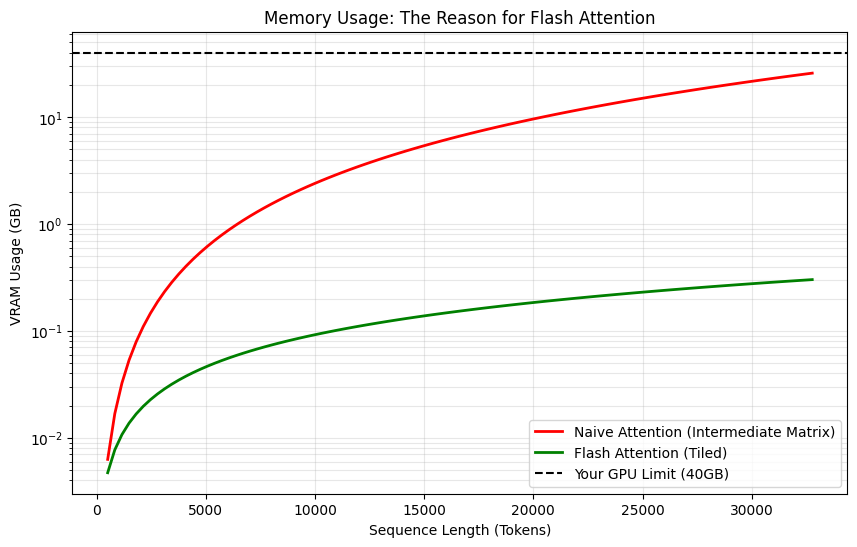

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_memory_comparison(gpu_vram_gb=40):
    # Sequence lengths from 512 to 32k
    n_range = np.linspace(512, 32768, 100)
    d = 128  # Head dimension
    h = 12   # Number of heads (standard for BERT-base/GPT-2)
    
    # 1. Naive Memory Usage (O(N^2))
    # Formula: (N * N) * heads * 2 bytes (for FP16)
    naive_mem_gb = (n_range**2 * h * 2) / 1e9
    
    # 2. Flash Attention Memory Usage (O(N))
    # Formula: (N * d) * heads * 2 bytes * constant_factor
    # (Flash mostly just stores the inputs/outputs)
    flash_mem_gb = (n_range * d * h * 6) / 1e9 # approx 3x input size
    
    plt.figure(figsize=(10, 6))
    plt.plot(n_range, naive_mem_gb, label='Naive Attention (Intermediate Matrix)', color='red', lw=2)
    plt.plot(n_range, flash_mem_gb, label='Flash Attention (Tiled)', color='green', lw=2)
    
    # Draw the "VRAM Wall"
    plt.axhline(y=gpu_vram_gb, color='black', linestyle='--', label=f'Your GPU Limit ({gpu_vram_gb}GB)')
    
    plt.yscale('log')
    plt.title('Memory Usage: The Reason for Flash Attention')
    plt.xlabel('Sequence Length (Tokens)')
    plt.ylabel('VRAM Usage (GB)')
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

plot_memory_comparison(gpu_vram_gb=40) # 40GB for A100